<a href="https://colab.research.google.com/github/hayahanyyy/Bachelor-Thesis/blob/main/Dataset2Last_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
df= pd.read_csv('AI_Personalized_Learning.csv')

In [3]:
df.head()

,student_id,age,gender,education_level,learning_style,previous_gpa,completed_modules,avg_time_per_module,engagement_score,distraction_events,quiz_accuracy,feedback_score,contextual_difficulty_level,recommended_path,actual_path_followed,path_efficiency_score,final_assessment_score,learning_outcome
0,STU001,20,Male,UG,Visual,3.75,5,42.70,67,4,100,4,Medium,M1→M2→M4,M1→M3→M5,84,69,Excellent
1,STU002,24,Female,UG,Kinesthetic,2.55,3,31.29,65,2,79,2,Medium,M1→M3→M5,M1→M3→M5,83,68,Fail
2,STU003,22,Male,PG,Visual,3.51,6,52.92,84,5,70,1,Medium,M1→M3→M5,M1→M2→M4,77,84,Good
3,STU004,23,Female,High School,Auditory,3.52,4,40.10,79,0,65,3,Medium,M1→M3→M5,M1→M2→M4,78,91,Fair
4,STU005,21,Female,High School,Kinesthetic,3.19,10,35.34,72,3,50,5,Hard,M1→M2→M4,M1→M3→M5,75,68,Fair


In [4]:
df = df.drop(columns=['student_id'], errors='ignore')

In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 age                            0
gender                         0
education_level                0
learning_style                 0
previous_gpa                   0
completed_modules              0
avg_time_per_module            0
engagement_score               0
distraction_events             0
quiz_accuracy                  0
feedback_score                 0
contextual_difficulty_level    0
recommended_path               0
actual_path_followed           0
path_efficiency_score          0
final_assessment_score         0
learning_outcome               0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1000 non-null   int64  
 1   gender                       1000 non-null   object 
 2   education_level              1000 non-null   object 
 3   learning_style               1000 non-null   object 
 4   previous_gpa                 1000 non-null   float64
 5   completed_modules            1000 non-null   int64  
 6   avg_time_per_module          1000 non-null   float64
 7   engagement_score             1000 non-null   int64  
 8   distraction_events           1000 non-null   int64  
 9   quiz_accuracy                1000 non-null   int64  
 10  feedback_score               1000 non-null   int64  
 11  contextual_difficulty_level  1000 non-null   object 
 12  recommended_path             1000 non-null   object 
 13  actual_path_followe

In [7]:
X = df.drop(columns=['learning_outcome'])
y = df['learning_outcome']

In [8]:
# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

Seperating columns

In [9]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("\nCategorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['gender', 'education_level', 'learning_style', 'contextual_difficulty_level', 'recommended_path', 'actual_path_followed']
Numerical: ['age', 'previous_gpa', 'completed_modules', 'avg_time_per_module', 'engagement_score', 'distraction_events', 'quiz_accuracy', 'feedback_score', 'path_efficiency_score', 'final_assessment_score']


In [10]:
# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())   # IMPORTANT for SVM & Logistic
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Initializing models

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel='rbf'),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )
}

In [13]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.22
              precision    recall  f1-score   support

   Excellent       0.27      0.30      0.28        53
        Fail       0.18      0.16      0.17        50
        Fair       0.25      0.21      0.23        47
        Good       0.18      0.20      0.19        50

    accuracy                           0.22       200
   macro avg       0.22      0.22      0.22       200
weighted avg       0.22      0.22      0.22       200


===== Random Forest =====
Accuracy: 0.21
              precision    recall  f1-score   support

   Excellent       0.24      0.28      0.26        53
        Fail       0.16      0.14      0.15        50
        Fair       0.24      0.19      0.21        47
        Good       0.19      0.22      0.21        50

    accuracy                           0.21       200
   macro avg       0.21      0.21      0.21       200
weighted avg       0.21      0.21      0.21       200


===== SVM =====
Accuracy: 0.23
        

Encoding categorical features

In [14]:
df = pd.get_dummies(df, drop_first=True)

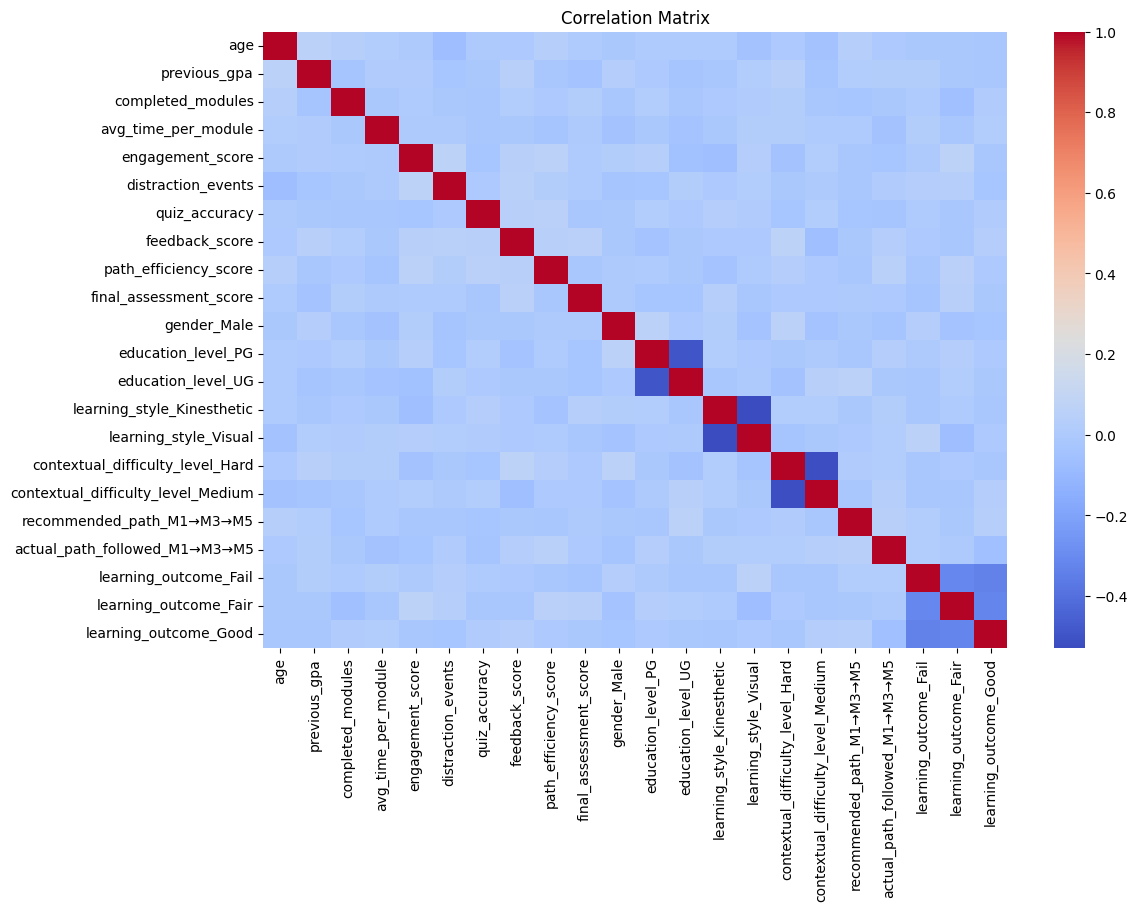

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

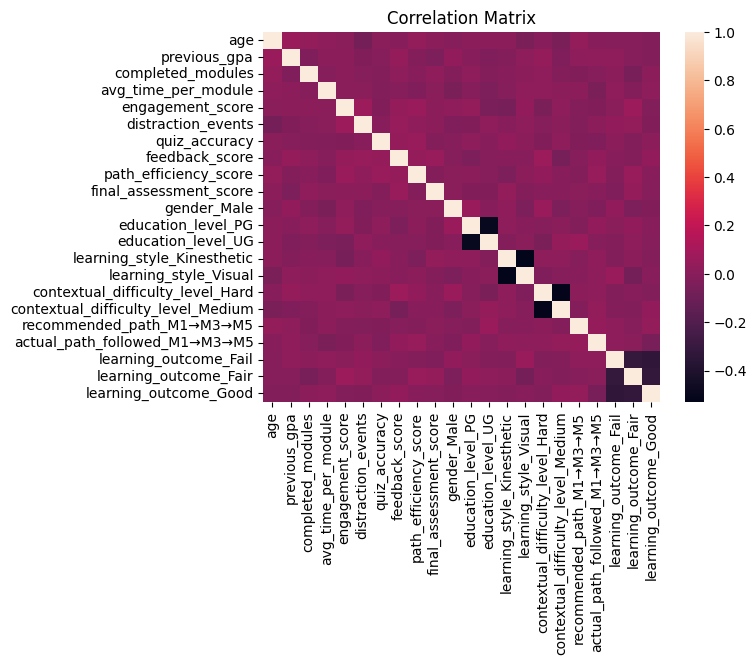

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr_matrix, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [17]:
# The error is KeyError: 'learning_outcome' because df.corr() was called after one-hot encoding
# the 'learning_outcome' column into multiple 'learning_outcome_CATEGORY' columns.
# The 'y' variable holds the label-encoded target.
# To get correlations with the target, we can create a temporary DataFrame
# consisting of numerical features and the label-encoded target.

# Create a DataFrame for correlation calculation with the label-encoded target
# X[num_cols] contains the numerical features (identified previously).
# y is the label-encoded learning_outcome.
correlation_df = X[num_cols].copy()
correlation_df['learning_outcome'] = y # Add the label-encoded target as a column

# Calculate the correlation matrix for this new DataFrame
full_corr_matrix = correlation_df.corr()

# Now, 'learning_outcome' exists as a column in full_corr_matrix
target_corr = full_corr_matrix['learning_outcome'].sort_values(ascending=False)
print(target_corr)

learning_outcome          1.000000
path_efficiency_score     0.024303
engagement_score          0.021568
feedback_score            0.018378
avg_time_per_module       0.016754
distraction_events        0.008443
final_assessment_score    0.004185
quiz_accuracy            -0.004550
previous_gpa             -0.028692
completed_modules        -0.031834
age                      -0.038600
Name: learning_outcome, dtype: float64


In [18]:
pd.Series(le.inverse_transform(y)).value_counts(normalize=True)

,proportion
Excellent,0.265
Good,0.252
Fail,0.249
Fair,0.234


Feature Engineering

In [20]:
df['performance_score'] = (
    df['quiz_accuracy'] +
    df['final_assessment_score'] +
    df['engagement_score']
) / 3

df['distraction_ratio'] = df['distraction_events'] / (df['avg_time_per_module'] + 1)

df['engagement_per_module'] = df['engagement_score'] / (df['completed_modules'] + 1)

In [27]:
df['learning_outcome'] = pd.cut(
    df['performance_score'],
    bins=[0, 50, 70, 90, 101],  # extend to 101
    labels=['Fail', 'Fair', 'Good', 'Excellent'],
    right=False
)

In [28]:
print(df['learning_outcome'].value_counts())

learning_outcome
Good         810
Fair         129
Excellent     61
Fail           0
Name: count, dtype: int64


In [23]:
df['learning_outcome'] = pd.cut(
    df['performance_score'],
    bins=[0, 40, 60, 80, 101],
    labels=['Fail', 'Fair', 'Good', 'Excellent'],
    right=False
)

In [24]:
print(df['learning_outcome'].value_counts())

learning_outcome
Good         576
Excellent    422
Fair           2
Fail           0
Name: count, dtype: int64


In [25]:
df['learning_outcome'] = pd.qcut(
    df['performance_score'],
    q=4,
    labels=['Fail', 'Fair', 'Good', 'Excellent']
)

In [26]:
print(df['learning_outcome'].value_counts())

learning_outcome
Fail         255
Fair         252
Excellent    250
Good         243
Name: count, dtype: int64


In [29]:
X = df.drop(columns=['learning_outcome', 'performance_score'])
y = df['learning_outcome']

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
from sklearn.preprocessing import OrdinalEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [35]:
# Re-define categorical and numerical columns based on the current X
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

# Re-define pipelines (these should use their latest definitions)
# num_pipeline definition from cell oBIgLJqn_AZl
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# cat_pipeline definition from cell Qr6DrXe0GPhp
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Re-create the preprocessor with the updated column lists and pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.975
              precision    recall  f1-score   support

   Excellent       1.00      0.83      0.91        12
        Fair       0.96      0.92      0.94        26
        Good       0.98      0.99      0.98       162

    accuracy                           0.97       200
   macro avg       0.98      0.92      0.94       200
weighted avg       0.98      0.97      0.97       200


===== Random Forest =====
Accuracy: 0.83
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00        12
        Fair       1.00      0.15      0.27        26
        Good       0.83      1.00      0.91       162

    accuracy                           0.83       200
   macro avg       0.61      0.38      0.39       200
weighted avg       0.80      0.83      0.77       200


===== SVM =====
Accuracy: 0.865
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00        12
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Accuracy: 0.95
              precision    recall  f1-score   support

   Excellent       1.00      0.92      0.96        12
        Fair       0.90      0.73      0.81        26
        Good       0.95      0.99      0.97       162

    accuracy                           0.95       200
   macro avg       0.95      0.88      0.91       200
weighted avg       0.95      0.95      0.95       200



In [37]:
df['learning_outcome'] = pd.qcut(
    df['performance_score'],
    q=4,
    labels=['Fail', 'Fair', 'Good', 'Excellent']
)

In [38]:
X = df.drop(columns=['learning_outcome', 'performance_score'])
y = df['learning_outcome']

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
from sklearn.preprocessing import OrdinalEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [42]:
# Re-define categorical and numerical columns based on the current X
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

# Re-define pipelines (these should use their latest definitions)
# num_pipeline definition from cell oBIgLJqn_AZl
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# cat_pipeline definition from cell Qr6DrXe0GPhp
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Re-create the preprocessor with the updated column lists and pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.925
              precision    recall  f1-score   support

   Excellent       0.94      0.92      0.93        50
        Fail       0.94      0.92      0.93        51
        Fair       0.92      0.92      0.92        50
        Good       0.90      0.94      0.92        49

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200


===== Random Forest =====
Accuracy: 0.77
              precision    recall  f1-score   support

   Excellent       0.84      0.94      0.89        50
        Fail       0.86      0.86      0.86        51
        Fair       0.65      0.68      0.67        50
        Good       0.71      0.59      0.64        49

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200


===== SVM =====
Accuracy: 0.775
      